<a href="https://colab.research.google.com/github/yuva0567890/23MID0421APAassignment5/blob/main/APA5DATASET1_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install vaderSentiment

In [2]:
import os
import re
import json
import time
import platform
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

SEED = 42

np.random.seed(SEED)

print("Python version:", platform.python_version())
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Python version: 3.13.15
NumPy version: 2.1.3
Pandas version: 2.2.3


In [3]:
DATA_PATH = "/content/Tweets.csv"

raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", raw.shape)

Dataset loaded successfully.
Shape: (14640, 15)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#Inspect the dataset
print("Columns:")
print(raw.columns.tolist())

Columns:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


In [6]:
raw.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [7]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [8]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tweet_id,14640.0,NaN,NaN,NaN,569218351767499200.0,779111158481836.75,567588278875213824.0,568559178101439488.0,569477857923110912.0,569890473289000960.0,570310600460525568.0
airline_sentiment,14640,3,negative,9178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airline_sentiment_confidence,14640.0,NaN,NaN,NaN,0.900169,0.16283,0.335,0.6923,1.0,1.0,1.0
negativereason,9178,10,Customer Service Issue,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
negativereason_confidence,10522.0,NaN,NaN,NaN,0.638298,0.33044,0.0,0.3606,0.6706,1.0,1.0
airline,14640,6,United,3822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airline_sentiment_gold,40,3,negative,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,14640,7701,JetBlueNews,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
negativereason_gold,32,13,Customer Service Issue,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
retweet_count,14640.0,NaN,NaN,NaN,0.08265,0.745778,0.0,0.0,0.0,0.0,44.0


In [9]:
#Data Audit
#Check missing values
missing = raw.isnull().sum()

missing_percentage = (missing / len(raw)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage
})

missing_table.sort_values(
    "Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
negativereason_gold,14608,99.781421
airline_sentiment_gold,14600,99.726776
tweet_coord,13621,93.039617
negativereason,5462,37.308743
user_timezone,4820,32.923497
tweet_location,4733,32.329235
negativereason_confidence,4118,28.128415
airline,0,0.000000
tweet_id,0,0.000000
airline_sentiment,0,0.000000


In [10]:
#check duplicate tweets
print("Duplicate tweet IDs:", raw["tweet_id"].duplicated().sum())

print("Duplicate tweet texts:", raw["text"].duplicated().sum())

Duplicate tweet IDs: 155
Duplicate tweet texts: 213


In [11]:
duplicate_texts = raw[raw["text"].duplicated(keep=False)].sort_values("text")

duplicate_texts[["tweet_id", "airline", "airline_sentiment", "text"]].head(20)

,tweet_id,airline,airline_sentiment,text
12067,570301488192458752,American,negative,.@AmericanAir can you connect me to a person w...
11906,570301488192458752,American,negative,.@AmericanAir can you connect me to a person w...
11902,570303383782989824,American,neutral,.@AmericanAir just disappointed with the Fligh...
12063,570303383782989824,American,neutral,.@AmericanAir just disappointed with the Fligh...
11946,570288282413633536,American,negative,@AmericanAir\n Your response could have made a...
12107,570288282413633536,American,negative,@AmericanAir\n Your response could have made a...
12128,570281010606120960,American,negative,@AmericanAir \nIt's not what happens to us tha...
11967,570281010606120960,American,negative,@AmericanAir \nIt's not what happens to us tha...
13995,569680231012773888,American,negative,@AmericanAir 800 number will not even let you...
12029,569680231012773888,American,negative,@AmericanAir 800 number will not even let you...


In [12]:
#Check target distribution
sentiment_counts = raw["airline_sentiment"].value_counts()

print(sentiment_counts)

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [13]:
sentiment_percentage = (
    raw["airline_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentage)

airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64


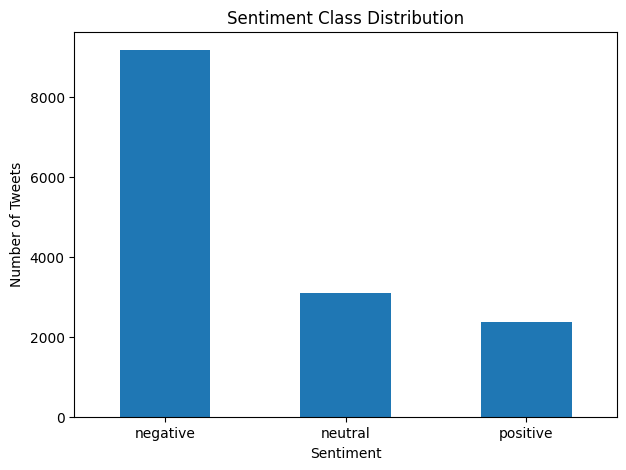

In [14]:
#Plot class distribution
plt.figure(figsize=(7, 5))

raw["airline_sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.show()

In [15]:
print(raw["airline"].value_counts())

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64


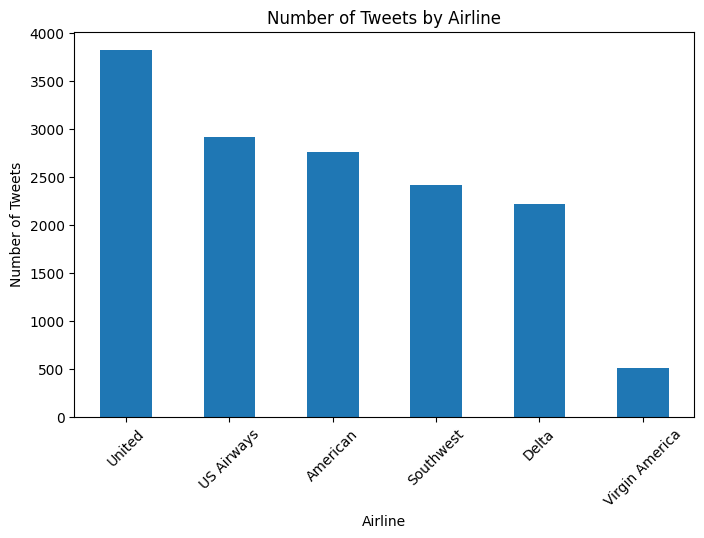

In [16]:
#Airline distribution
plt.figure(figsize=(8, 5))

raw["airline"].value_counts().plot(kind="bar")

plt.title("Number of Tweets by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.show()

In [17]:
#Sentiment by airline
airline_sentiment = pd.crosstab(
    raw["airline"],
    raw["airline_sentiment"]
)

airline_sentiment

airline_sentiment,negative,neutral,positive
airline,,,
American,1960,463,336
Delta,955,723,544
Southwest,1186,664,570
US Airways,2263,381,269
United,2633,697,492
Virgin America,181,171,152


In [18]:
airline_sentiment_percentage = pd.crosstab(
    raw["airline"],
    raw["airline_sentiment"],
    normalize="index"
) * 100

airline_sentiment_percentage.round(2)

airline_sentiment,negative,neutral,positive
airline,,,
American,71.04,16.78,12.18
Delta,42.98,32.54,24.48
Southwest,49.01,27.44,23.55
US Airways,77.69,13.08,9.23
United,68.89,18.24,12.87
Virgin America,35.91,33.93,30.16


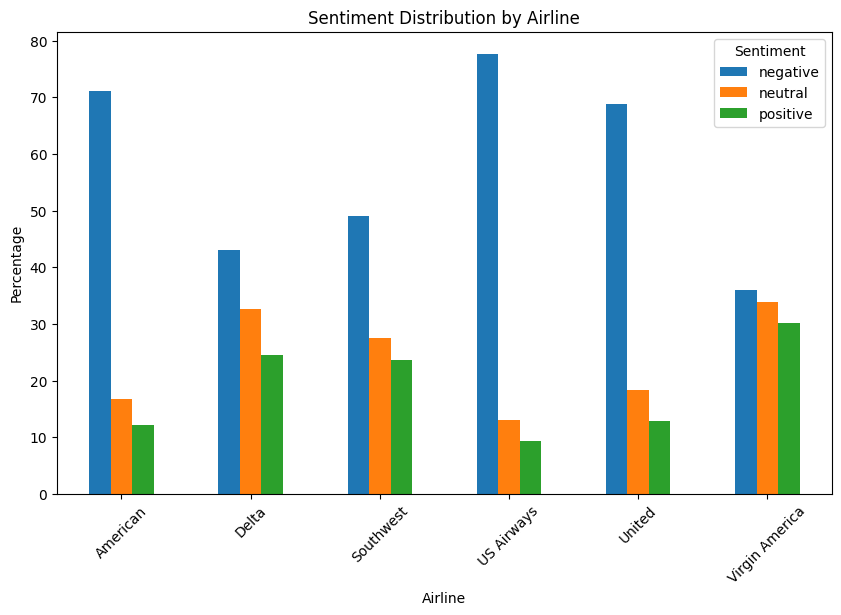

In [19]:
airline_sentiment_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.show()

In [20]:
#Tweet length analysis
raw["tweet_length"] = raw["text"].astype(str).str.len()

raw["tweet_word_count"] = (
    raw["text"]
    .astype(str)
    .str.split()
    .str.len()
)

In [21]:
raw[["tweet_length", "tweet_word_count"]].describe()

,tweet_length,tweet_word_count
count,14640.000000,14640.000000
mean,103.822063,17.653415
std,36.277339,6.882259
min,12.000000,2.000000
25%,77.000000,12.000000
50%,114.000000,19.000000
75%,136.000000,23.000000
max,186.000000,36.000000


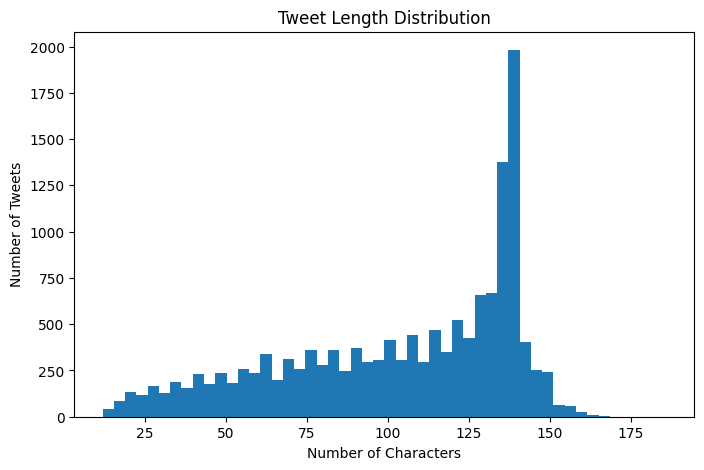

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(raw["tweet_length"], bins=50)

plt.title("Tweet Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")

plt.show()

In [23]:
#Leakage audit
leakage_columns = [
    "tweet_id",
    "airline_sentiment_confidence",
    "negativereason",
    "negativereason_confidence",
    "airline_sentiment_gold",
    "name",
    "negativereason_gold",
    "tweet_coord",
    "tweet_location",
    "user_timezone"
]

print("Excluded columns:")
for col in leakage_columns:
    print("-", col)

Excluded columns:
- tweet_id
- airline_sentiment_confidence
- negativereason
- negativereason_confidence
- airline_sentiment_gold
- name
- negativereason_gold
- tweet_coord
- tweet_location
- user_timezone


In [24]:
#Keep only useful columns
df = raw[
    [
        "tweet_id",
        "text",
        "airline",
        "airline_sentiment"
    ]
].copy()

df.head()

,tweet_id,text,airline,airline_sentiment
0,570306133677760513,@VirginAmerica What @dhepburn said.,Virgin America,neutral
1,570301130888122368,@VirginAmerica plus you've added commercials t...,Virgin America,positive
2,570301083672813571,@VirginAmerica I didn't today... Must mean I n...,Virgin America,neutral
3,570301031407624196,@VirginAmerica it's really aggressive to blast...,Virgin America,negative
4,570300817074462722,@VirginAmerica and it's a really big bad thing...,Virgin America,negative


In [25]:
#Remove missing target/text
df = df.dropna(
    subset=["text", "airline_sentiment"]
).copy()

df["text"] = df["text"].astype(str)

print(df.shape)

(14640, 4)


In [26]:
#Minimal tweet preprocessing
def normalize_tweet(text):
    text = str(text)

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " <URL> ",
        text
    )

    text = re.sub(
        r"@\w+",
        " <USER> ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [27]:
df["clean_text"] = df["text"].apply(normalize_tweet)

df[["text", "clean_text"]].head(10)

,text,clean_text
0,@VirginAmerica What @dhepburn said.,<USER> What <USER> said.
1,@VirginAmerica plus you've added commercials t...,<USER> plus you've added commercials to the ex...
2,@VirginAmerica I didn't today... Must mean I n...,<USER> I didn't today... Must mean I need to t...
3,@VirginAmerica it's really aggressive to blast...,<USER> it's really aggressive to blast obnoxio...
4,@VirginAmerica and it's a really big bad thing...,<USER> and it's a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,<USER> seriously would pay $30 a flight for se...
6,"@VirginAmerica yes, nearly every time I fly VX...","<USER> yes, nearly every time I fly VX this “e..."
7,@VirginAmerica Really missed a prime opportuni...,<USER> Really missed a prime opportunity for M...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D","<USER> Well, I didn't…but NOW I DO! :-D"
9,"@VirginAmerica it was amazing, and arrived an ...","<USER> it was amazing, and arrived an hour ear..."


In [28]:
# This code checks whether duplicated tweet texts have consistent or conflicting sentiment labels.

text_label_check = (
    df.groupby("clean_text")["airline_sentiment"]
    .nunique()
    .sort_values(ascending=False)
)

conflicting_texts = text_label_check[text_label_check > 1]

print("Number of text groups with conflicting sentiment labels:",
      len(conflicting_texts))

if len(conflicting_texts) > 0:
    print("\nExamples of conflicting duplicate texts:")
    print(
        df[df["clean_text"].isin(conflicting_texts.index)]
        [["clean_text", "airline", "airline_sentiment"]]
        .sort_values("clean_text")
        .head(20)
    )

Number of text groups with conflicting sentiment labels: 36

Examples of conflicting duplicate texts:
                                              clean_text     airline  \
12134  <USER> "Airport snow removal method #22..." Ke...    American   
9025   <USER> "Airport snow removal method #22..." Ke...  US Airways   
558    <USER> "Airport snow removal method #22..." Ke...      United   
11973  <USER> "Airport snow removal method #22..." Ke...    American   
8123   <USER> 's CEO battles to appease passengers an...       Delta   
8431   <USER> 's CEO battles to appease passengers an...       Delta   
8109   <USER> 's CEO battles to appease passengers an...       Delta   
6972   <USER> 's CEO battles to appease passengers an...       Delta   
8307   <USER> 's CEO battles to appease passengers an...       Delta   
7175   <USER> 's CEO battles to appease passengers an...       Delta   
8596   <USER> 's CEO battles to appease passengers an...       Delta   
8054   <USER> 's CEO battles to ap

In [29]:
# This code displays examples of exact duplicate tweet texts whose sentiment labels are identical.

consistent_duplicates = (
    df[df["clean_text"].duplicated(keep=False)]
    .sort_values("clean_text")
)

print("Rows involved in duplicate text groups:",
      len(consistent_duplicates))

consistent_duplicates[
    ["tweet_id", "airline", "airline_sentiment", "clean_text"]
].head(20)

Rows involved in duplicate text groups: 555


,tweet_id,airline,airline_sentiment,clean_text
12067,570301488192458752,American,negative,. <USER> can you connect me to a person withou...
11906,570301488192458752,American,negative,. <USER> can you connect me to a person withou...
12063,570303383782989824,American,neutral,. <USER> just disappointed with the Flight Boo...
11902,570303383782989824,American,neutral,. <USER> just disappointed with the Flight Boo...
9025,570279050276704257,US Airways,neutral,"<USER> ""Airport snow removal method #22..."" Ke..."
12134,570279653337927680,American,positive,"<USER> ""Airport snow removal method #22..."" Ke..."
11973,570279653337927680,American,positive,"<USER> ""Airport snow removal method #22..."" Ke..."
558,570279720937529345,United,positive,"<USER> ""Airport snow removal method #22..."" Ke..."
8615,568108968867819520,Delta,neutral,"<USER> 's CEO #pilots among ardent fans, Wall ..."
8143,568727789311889409,Delta,neutral,"<USER> 's CEO #pilots among ardent fans, Wall ..."


In [30]:
#Creates a clean working dataframe containing only the variables required for modeling and entity analysis.

model_df = df[
    [
        "tweet_id",
        "clean_text",
        "airline",
        "airline_sentiment"
    ]
].copy()

print("Modeling dataframe shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nTarget distribution:")
print(model_df["airline_sentiment"].value_counts())

Modeling dataframe shape: (14640, 4)

Columns:
['tweet_id', 'clean_text', 'airline', 'airline_sentiment']

Target distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [31]:
# This code removes repeated tweet IDs while keeping the first occurrence of each tweet record.

before_id_dedup = len(model_df)

model_df = model_df.drop_duplicates(
    subset="tweet_id",
    keep="first"
).reset_index(drop=True)

after_id_dedup = len(model_df)

print("Rows before tweet-ID deduplication:", before_id_dedup)
print("Rows after tweet-ID deduplication:", after_id_dedup)
print("Rows removed:", before_id_dedup - after_id_dedup)

Rows before tweet-ID deduplication: 14640
Rows after tweet-ID deduplication: 14485
Rows removed: 155


In [32]:
# This code measures exact duplicate tweet texts after tweet-ID deduplication.

duplicate_text_count = model_df["clean_text"].duplicated().sum()

print("Duplicate texts after tweet-ID deduplication:",
      duplicate_text_count)

Duplicate texts after tweet-ID deduplication: 181


In [33]:
# This code separates the tweet text, sentiment target, and airline context for the experiment.

X_text = model_df["clean_text"]

y = model_df["airline_sentiment"]

airline_context = model_df["airline"]

print("Number of text samples:", len(X_text))
print("Number of target labels:", len(y))

print("\nTarget classes:")
print(sorted(y.unique()))

Number of text samples: 14485
Number of target labels: 14485

Target classes:
['negative', 'neutral', 'positive']


In [34]:
#Fixed random seed that will be used throughout the experiment.

SEED = 42

np.random.seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [35]:
#Creates a stratified 70% training set and a temporary 30% set for validation and testing.

X_train, X_temp, y_train, y_temp, airline_train, airline_temp = train_test_split(
    X_text,
    y,
    airline_context,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Temporary samples:", len(X_temp))

Training samples: 10139
Temporary samples: 4346


In [36]:
#Splits the temporary 30% subset equally into validation and locked test sets while preserving class proportions.

X_val, X_test, y_val, y_test, airline_val, airline_test = train_test_split(
    X_temp,
    y_temp,
    airline_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 10139
Validation samples: 2173
Test samples: 2173


In [37]:
#Verify class proportions
split_distribution = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True) * 100,
    "Validation": y_val.value_counts(normalize=True) * 100,
    "Test": y_test.value_counts(normalize=True) * 100
}).round(2)

split_distribution

,Train,Validation,Test
airline_sentiment,,,
negative,62.70,62.68,62.72
neutral,21.19,21.21,21.17
positive,16.12,16.11,16.11


In [38]:
#Verify that the test set is locked
test_indices = X_test.index

print("Number of locked test observations:", len(test_indices))
print("First 10 test indices:")
print(test_indices[:10].tolist())

Number of locked test observations: 2173
First 10 test indices:
[6017, 9122, 7169, 4669, 13228, 13638, 8644, 12203, 8551, 10520]


In [39]:
#Create output folders

OUTPUT_DIR = "lab05_outputs"
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
ADVANCED_DIR = os.path.join(OUTPUT_DIR, "advanced")

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(ADVANCED_DIR, exist_ok=True)

print("Output directories created successfully.")

Output directories created successfully.


In [40]:
#Save the split information
split_indices = pd.DataFrame({
    "index": model_df.index,
    "split": "unused"
})

split_indices.loc[X_train.index, "split"] = "train"
split_indices.loc[X_val.index, "split"] = "validation"
split_indices.loc[X_test.index, "split"] = "test"

split_indices.to_csv(
    os.path.join(OUTPUT_DIR, "split_indices.csv"),
    index=False
)

print(split_indices["split"].value_counts())

split
train         10139
validation     2173
test           2173
Name: count, dtype: int64


In [41]:
#Models:: DummyClassifier Baseline

dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=SEED
)

dummy_model.fit(X_train, y_train)

dummy_val_pred = dummy_model.predict(X_val)

dummy_accuracy = accuracy_score(y_val, dummy_val_pred)
dummy_macro_f1 = f1_score(
    y_val,
    dummy_val_pred,
    average="macro"
)

print("DummyClassifier Results")
print("-----------------------")
print("Accuracy :", round(dummy_accuracy, 4))
print("Macro F1 :", round(dummy_macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        dummy_val_pred,
        digits=4
    )
)

DummyClassifier Results
-----------------------
Accuracy : 0.6268
Macro F1 : 0.2569

Classification Report:
              precision    recall  f1-score   support

    negative     0.6268    1.0000    0.7706      1362
     neutral     0.0000    0.0000    0.0000       461
    positive     0.0000    0.0000    0.0000       350

    accuracy                         0.6268      2173
   macro avg     0.2089    0.3333    0.2569      2173
weighted avg     0.3929    0.6268    0.4830      2173



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
# Model::VADER Baseline

vader_analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = vader_analyzer.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

vader_val_pred = X_val.apply(vader_predict)

vader_accuracy = accuracy_score(
    y_val,
    vader_val_pred
)

vader_macro_f1 = f1_score(
    y_val,
    vader_val_pred,
    average="macro"
)

print("VADER Results")
print("-------------")
print("Accuracy :", round(vader_accuracy, 4))
print("Macro F1 :", round(vader_macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        vader_val_pred,
        digits=4
    )
)

VADER Results
-------------
Accuracy : 0.5453
Macro F1 : 0.5107

Classification Report:
              precision    recall  f1-score   support

    negative     0.9056    0.5000    0.6443      1362
     neutral     0.3867    0.4035    0.3949       461
    positive     0.3383    0.9086    0.4930       350

    accuracy                         0.5453      2173
   macro avg     0.5435    0.6040    0.5107      2173
weighted avg     0.7041    0.5453    0.5670      2173



In [43]:
# Baseline Comparison

baseline_results = pd.DataFrame({
    "Model": [
        "DummyClassifier",
        "VADER"
    ],
    "Accuracy": [
        dummy_accuracy,
        vader_accuracy
    ],
    "Macro_F1": [
        dummy_macro_f1,
        vader_macro_f1
    ]
})

baseline_results

,Model,Accuracy,Macro_F1
0,DummyClassifier,0.626783,0.256860
1,VADER,0.545329,0.510735


In [44]:
#Model:: Logistic Regression

logistic_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_val_pred = logistic_model.predict(X_val)

logistic_accuracy = accuracy_score(
    y_val,
    logistic_val_pred
)

logistic_macro_f1 = f1_score(
    y_val,
    logistic_val_pred,
    average="macro"
)

logistic_weighted_f1 = f1_score(
    y_val,
    logistic_val_pred,
    average="weighted"
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy    :", round(logistic_accuracy, 4))
print("Macro F1    :", round(logistic_macro_f1, 4))
print("Weighted F1 :", round(logistic_weighted_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        logistic_val_pred,
        digits=4
    )
)

Logistic Regression Results
---------------------------
Accuracy    : 0.7929
Macro F1    : 0.7484
Weighted F1 : 0.7971

Classification Report:
              precision    recall  f1-score   support

    negative     0.8939    0.8348    0.8633      1362
     neutral     0.6056    0.7093    0.6533       461
    positive     0.7175    0.7400    0.7286       350

    accuracy                         0.7929      2173
   macro avg     0.7390    0.7614    0.7484      2173
weighted avg     0.8043    0.7929    0.7971      2173



Confusion Matrix:
[[1137  159   66]
 [  98  327   36]
 [  37   54  259]]


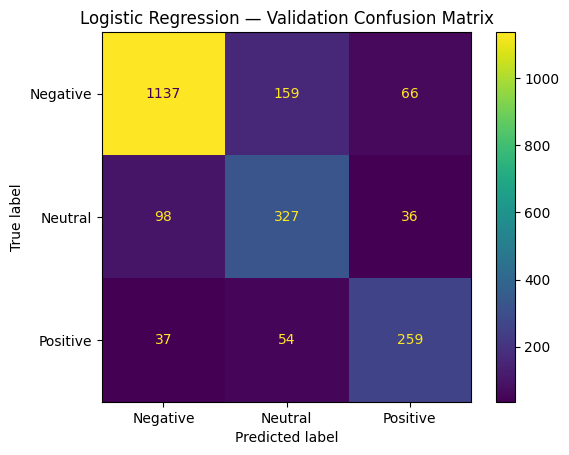

In [45]:
#Logistic Regression Confusion Matrix

logistic_cm = confusion_matrix(
    y_val,
    logistic_val_pred,
    labels=["negative", "neutral", "positive"]
)

print("Confusion Matrix:")
print(logistic_cm)

ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["Negative", "Neutral", "Positive"]
).plot()

plt.title("Logistic Regression — Validation Confusion Matrix")
plt.show()

In [46]:
#TensorFlow Setup

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [47]:
#  BiLSTM Tokenization

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 30000
MAX_LENGTH = 80

bilstm_tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

bilstm_tokenizer.fit_on_texts(
    X_train.tolist()
)

X_train_seq = bilstm_tokenizer.texts_to_sequences(
    X_train.tolist()
)

X_val_seq = bilstm_tokenizer.texts_to_sequences(
    X_val.tolist()
)

X_test_seq = bilstm_tokenizer.texts_to_sequences(
    X_test.tolist()
)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape :", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape     :", X_test_pad.shape)

Training shape : (10139, 80)
Validation shape: (2173, 80)
Test shape     : (2173, 80)


In [48]:
#BiLSTM Label Encoding

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_val_encoded = label_encoder.transform(
    y_val
)

y_test_encoded = label_encoder.transform(
    y_test
)

print("Classes:")
print(label_encoder.classes_)

print("\nEncoded labels:")
print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

Classes:
['negative' 'neutral' 'positive']

Encoded labels:
{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [49]:
#BiLSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

bilstm_model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    ),

    Dropout(0.4),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        3,
        activation="softmax"
    )
])

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
#BiLSTM Class Weights

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_encoded)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

bilstm_class_weights = dict(
    zip(
        classes,
        class_weights_array
    )
)

print("Class weights:")
print(bilstm_class_weights)

Class weights:
{np.int64(0): np.float64(0.5316449058780347), np.int64(1): np.float64(1.5734016139044071), np.int64(2): np.float64(2.0683394532843735)}


In [51]:
#BiLSTM Training

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

bilstm_start_time = time.time()

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(
        X_val_pad,
        y_val_encoded
    ),
    epochs=8,
    batch_size=64,
    class_weight=bilstm_class_weights,
    callbacks=[early_stopping],
    verbose=1
)

bilstm_training_time = time.time() - bilstm_start_time

print(
    "\nBiLSTM training time:",
    round(bilstm_training_time, 2),
    "seconds"
)

Epoch 1/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.6079 - loss: 0.8721 - val_accuracy: 0.7782 - val_loss: 0.5603
Epoch 2/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8194 - loss: 0.5089 - val_accuracy: 0.7814 - val_loss: 0.5873
Epoch 3/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8823 - loss: 0.3272 - val_accuracy: 0.7911 - val_loss: 0.6026

BiLSTM training time: 32.96 seconds


In [52]:
# BiLSTM Validation Evaluation

bilstm_val_prob = bilstm_model.predict(
    X_val_pad,
    verbose=0
)

bilstm_val_pred_encoded = np.argmax(
    bilstm_val_prob,
    axis=1
)

bilstm_val_pred = label_encoder.inverse_transform(
    bilstm_val_pred_encoded
)

bilstm_accuracy = accuracy_score(
    y_val,
    bilstm_val_pred
)

bilstm_macro_f1 = f1_score(
    y_val,
    bilstm_val_pred,
    average="macro"
)

bilstm_weighted_f1 = f1_score(
    y_val,
    bilstm_val_pred,
    average="weighted"
)

print("BiLSTM Results")
print("--------------")
print("Accuracy    :", round(bilstm_accuracy, 4))
print("Macro F1    :", round(bilstm_macro_f1, 4))
print("Weighted F1 :", round(bilstm_weighted_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        bilstm_val_pred,
        digits=4
    )
)

BiLSTM Results
--------------
Accuracy    : 0.7782
Macro F1    : 0.7049
Weighted F1 : 0.7745

Classification Report:
              precision    recall  f1-score   support

    negative     0.8684    0.8722    0.8703      1362
     neutral     0.6579    0.4881    0.5604       461
    positive     0.6004    0.7943    0.6839       350

    accuracy                         0.7782      2173
   macro avg     0.7089    0.7182    0.7049      2173
weighted avg     0.7806    0.7782    0.7745      2173



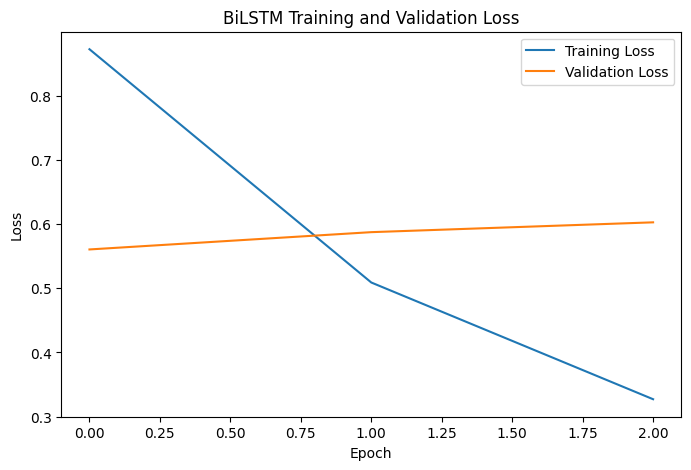

In [53]:
#BiLSTM Training Curves

plt.figure(figsize=(8, 5))

plt.plot(
    bilstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    bilstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("BiLSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

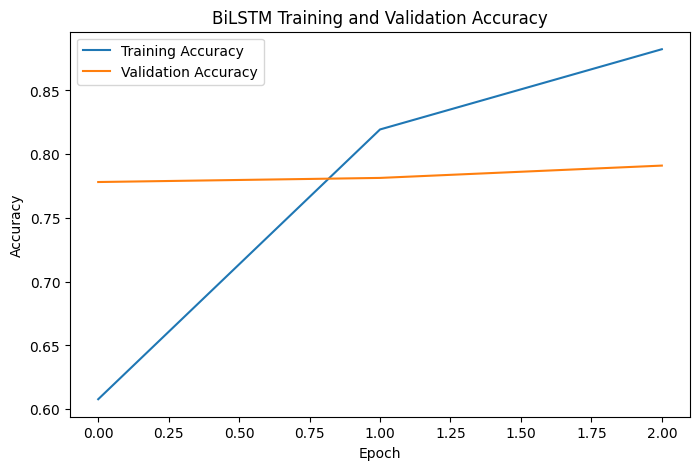

In [54]:
#A — BiLSTM Accuracy Curve

plt.figure(figsize=(8, 5))

plt.plot(
    bilstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    bilstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("BiLSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [55]:
#BERTweet Installation

!pip -q install -U transformers datasets accelerate

In [56]:
# Step 42A — Fix PyArrow

!pip install -q --upgrade --force-reinstall pyarrow

In [57]:
# Step 42B — Verify PyArrow

import pyarrow as pa

print("PyArrow version:", pa.__version__)

PyArrow version: 25.0.1


In [58]:
# Step 1 — Install BERTweet Dependencies

!pip install -q -U transformers datasets accelerate pyarrow

In [59]:
# Step 2 — Check Dependencies

import pyarrow
import torch
import transformers
import datasets

print("PyArrow:", pyarrow.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA:", torch.cuda.is_available())

PyArrow: 25.0.1
Transformers: 5.15.1
Datasets: 5.0.1
CUDA: True


In [60]:
# Step 3 — BERTweet Imports

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("BERTweet imports successful.")

BERTweet imports successful.


In [61]:
# Step 42C — Verify Transformers

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [62]:
#Check PyArrow

import pyarrow

print(pyarrow.__version__)

25.0.1


In [63]:
# Check Transformers

import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
Transformers: 5.15.1
CUDA: True


In [64]:
# BERTweet Imports

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [65]:
#BERTweet Tokenizer

BERTWEET_MODEL = "vinai/bertweet-base"

bertweet_tokenizer = AutoTokenizer.from_pretrained(
    BERTWEET_MODEL,
    use_fast=False
)

print("BERTweet tokenizer loaded successfully.")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


BERTweet tokenizer loaded successfully.


In [66]:
#Restore Imports

import numpy as np
import pandas as pd

from datasets import Dataset

print("Imports restored.")

Imports restored.


In [67]:
# Step 45B — Check Split Variables

print("X_train:", len(X_train))
print("X_val:", len(X_val))
print("X_test:", len(X_test))

print("y_train:", len(y_train))
print("y_val:", len(y_val))
print("y_test:", len(y_test))

X_train: 10139
X_val: 2173
X_test: 2173
y_train: 10139
y_val: 2173
y_test: 2173


In [68]:
#BERTweet Dataset Preparation

from datasets import Dataset

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

train_bert_df = pd.DataFrame({
    "text": X_train.tolist(),
    "label": y_train.map(label2id).tolist()
})

val_bert_df = pd.DataFrame({
    "text": X_val.tolist(),
    "label": y_val.map(label2id).tolist()
})

test_bert_df = pd.DataFrame({
    "text": X_test.tolist(),
    "label": y_test.map(label2id).tolist()
})

train_dataset = Dataset.from_pandas(
    train_bert_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_bert_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_bert_df,
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 10139
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2173
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2173
})


In [69]:
# BERTweet Tokenization

def tokenize_bertweet(batch):
    return bertweet_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_bertweet,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_bertweet,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_bertweet,
    batched=True
)

print("BERTweet tokenization completed.")

Map:   0%|          | 0/10139 [00:00<?, ? examples/s]

Map:   0%|          | 0/2173 [00:00<?, ? examples/s]

Map:   0%|          | 0/2173 [00:00<?, ? examples/s]

BERTweet tokenization completed.


In [70]:
#BERTweet Model

bertweet_model = AutoModelForSequenceClassification.from_pretrained(
    BERTWEET_MODEL,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("BERTweet classification model loaded.")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTweet classification model loaded.


In [71]:
# BERTweet Metrics

def compute_metrics(eval_prediction):
    logits, labels = eval_prediction

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro"
        ),
        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted"
        )
    }

In [72]:
#BERTweet Training Configuration

bertweet_training_args = TrainingArguments(
    output_dir="./bertweet_airline_sentiment",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none",

    fp16=torch.cuda.is_available()
)

In [73]:
#BERTweet Trainer

bertweet_trainer = Trainer(
    model=bertweet_model,
    args=bertweet_training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    processing_class=bertweet_tokenizer,

    compute_metrics=compute_metrics
)

print("BERTweet Trainer created successfully.")

BERTweet Trainer created successfully.


In [74]:
# Step 51 — BERTweet Training

bertweet_start_time = time.time()

bertweet_trainer.train()

bertweet_training_time = time.time() - bertweet_start_time

print(
    "\nBERTweet training time:",
    round(bertweet_training_time, 2),
    "seconds"
)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.388313,0.399049,0.850437,0.809443,0.851119
2,0.294157,0.397882,0.867925,0.829287,0.867349
3,0.194638,0.445360,0.865163,0.826106,0.865609


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


BERTweet training time: 301.06 seconds


In [75]:
#BERTweet Validation Evaluation

bertweet_eval = bertweet_trainer.evaluate(
    eval_dataset=val_dataset
)

print("BERTweet Validation Results")
print("---------------------------")

for key, value in bertweet_eval.items():
    if isinstance(value, float):
        print(key, ":", round(value, 4))
    else:
        print(key, ":", value)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.194638,0.397882,3,0.867925,0.829287,0.867349


BERTweet Validation Results
---------------------------
eval_loss : 0.3979
eval_accuracy : 0.8679
eval_macro_f1 : 0.8293
eval_weighted_f1 : 0.8673


In [76]:
#BERTweet Predictions

bertweet_output = bertweet_trainer.predict(
    test_dataset
)

bertweet_test_logits = bertweet_output.predictions

bertweet_test_pred_encoded = np.argmax(
    bertweet_test_logits,
    axis=1
)

bertweet_test_pred = [
    id2label[int(label)]
    for label in bertweet_test_pred_encoded
]

print("BERTweet test predictions generated.")
print("Number of predictions:", len(bertweet_test_pred))

BERTweet test predictions generated.
Number of predictions: 2173


In [77]:
#Model Validation Comparison

model_results = pd.DataFrame({
    "Model": [
        "DummyClassifier",
        "VADER",
        "Logistic Regression",
        "BiLSTM"
    ],
    "Accuracy": [
        dummy_accuracy,
        vader_accuracy,
        logistic_accuracy,
        bilstm_accuracy
    ],
    "Macro_F1": [
        dummy_macro_f1,
        vader_macro_f1,
        logistic_macro_f1,
        bilstm_macro_f1
    ],
    "Weighted_F1": [
        f1_score(y_val, dummy_val_pred, average="weighted"),
        f1_score(y_val, vader_val_pred, average="weighted"),
        logistic_weighted_f1,
        bilstm_weighted_f1
    ]
})

model_results.sort_values(
    "Macro_F1",
    ascending=False
)

,Model,Accuracy,Macro_F1,Weighted_F1
2,Logistic Regression,0.792913,0.748408,0.797071
3,BiLSTM,0.778187,0.704872,0.774548
1,VADER,0.545329,0.510735,0.567010
0,DummyClassifier,0.626783,0.256860,0.482987


In [78]:
#LinearSVC

linear_svc_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            random_state=SEED
        )
    )
])

linear_svc_model.fit(
    X_train,
    y_train
)

linear_svc_val_pred = linear_svc_model.predict(
    X_val
)

linear_svc_accuracy = accuracy_score(
    y_val,
    linear_svc_val_pred
)

linear_svc_macro_f1 = f1_score(
    y_val,
    linear_svc_val_pred,
    average="macro"
)

linear_svc_weighted_f1 = f1_score(
    y_val,
    linear_svc_val_pred,
    average="weighted"
)

print("LinearSVC Results")
print("-----------------")
print("Accuracy    :", round(linear_svc_accuracy, 4))
print("Macro F1    :", round(linear_svc_macro_f1, 4))
print("Weighted F1 :", round(linear_svc_weighted_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        linear_svc_val_pred,
        digits=4
    )
)

LinearSVC Results
-----------------
Accuracy    : 0.7943
Macro F1    : 0.737
Weighted F1 : 0.7935

Classification Report:
              precision    recall  f1-score   support

    negative     0.8619    0.8796    0.8706      1362
     neutral     0.6178    0.6312    0.6245       461
    positive     0.7596    0.6771    0.7160       350

    accuracy                         0.7943      2173
   macro avg     0.7464    0.7293    0.7370      2173
weighted avg     0.7936    0.7943    0.7935      2173



In [79]:
# Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_validate

cv1 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_scoring1 = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

logistic_cv1 = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv1,
    scoring=cv_scoring1,
    n_jobs=-1
)

linear_svc_cv1 = cross_validate(
    linear_svc_model,
    X_train,
    y_train,
    cv=cv1,
    scoring=cv_scoring1,
    n_jobs=-1
)

print("Cross-validation completed.")

Cross-validation completed.


In [80]:
# Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_validate

cv1 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scoring1 = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

logistic_cv1 = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv1,
    scoring=cv_scoring1,
    n_jobs=-1
)

linear_svc_cv1 = cross_validate(
    linear_svc_model,
    X_train,
    y_train,
    cv=cv1,
    scoring=cv_scoring1,
    n_jobs=-1
)

print("Cross-validation completed.")

Cross-validation completed.


In [81]:
# CV Results

cv_results1 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LinearSVC"
    ],
    "CV Macro F1 Mean": [
        logistic_cv1["test_macro_f1"].mean(),
        linear_svc_cv1["test_macro_f1"].mean()
    ],
    "CV Macro F1 SD": [
        logistic_cv1["test_macro_f1"].std(),
        linear_svc_cv1["test_macro_f1"].std()
    ],
    "CV Weighted F1 Mean": [
        logistic_cv1["test_weighted_f1"].mean(),
        linear_svc_cv1["test_weighted_f1"].mean()
    ],
    "CV Accuracy Mean": [
        logistic_cv1["test_accuracy"].mean(),
        linear_svc_cv1["test_accuracy"].mean()
    ]
})

display(cv_results1.round(4))

,Model,CV Macro F1 Mean,CV Macro F1 SD,CV Weighted F1 Mean,CV Accuracy Mean
0,Logistic Regression,0.7393,0.0134,0.7917,0.7893
1,LinearSVC,0.7394,0.0186,0.7961,0.7994


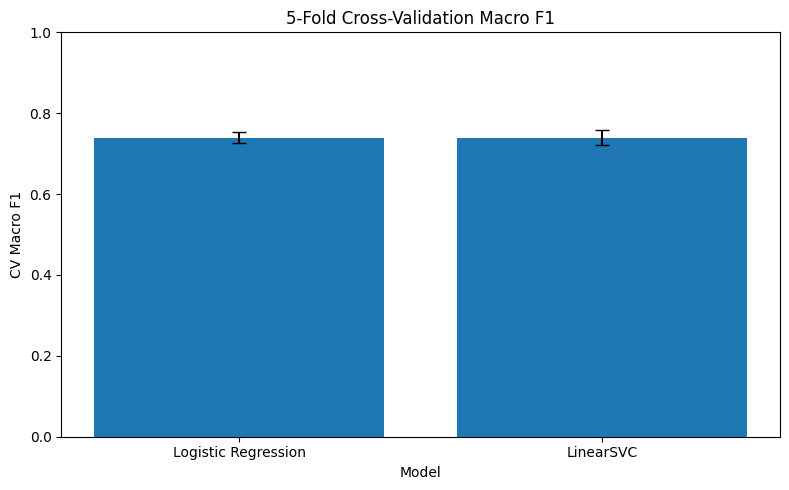

In [82]:
# CV Macro F1 Plot

plt.figure(figsize=(8, 5))

plt.bar(
    cv_results1["Model"],
    cv_results1["CV Macro F1 Mean"],
    yerr=cv_results1["CV Macro F1 SD"],
    capsize=5
)

plt.xlabel("Model")
plt.ylabel("CV Macro F1")
plt.title("5-Fold Cross-Validation Macro F1")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

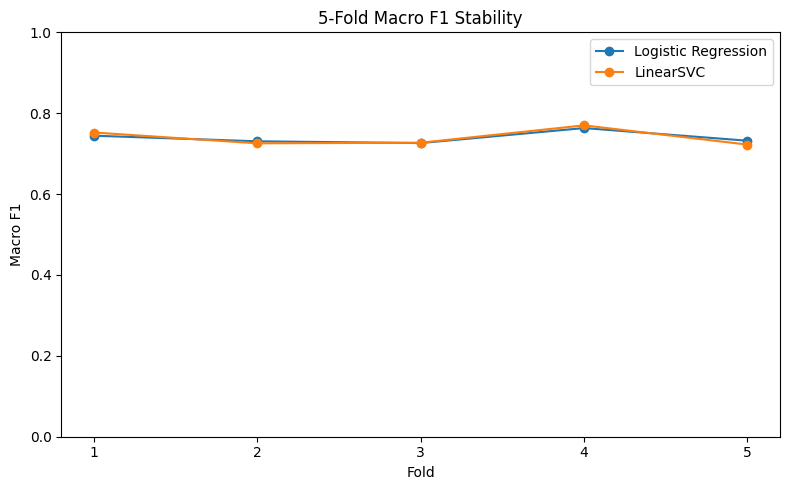

In [83]:
# Fold Stability Plot

fold_scores1 = pd.DataFrame({
    "Fold": range(1, 6),
    "Logistic Regression": logistic_cv1["test_macro_f1"],
    "LinearSVC": linear_svc_cv1["test_macro_f1"]
})

plt.figure(figsize=(8, 5))

plt.plot(
    fold_scores1["Fold"],
    fold_scores1["Logistic Regression"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    fold_scores1["Fold"],
    fold_scores1["LinearSVC"],
    marker="o",
    label="LinearSVC"
)

plt.xlabel("Fold")
plt.ylabel("Macro F1")
plt.title("5-Fold Macro F1 Stability")
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

In [84]:
# CV Results

cv_results1 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LinearSVC"
    ],
    "CV Macro F1 Mean": [
        logistic_cv1["test_macro_f1"].mean(),
        linear_svc_cv1["test_macro_f1"].mean()
    ],
    "CV Macro F1 SD": [
        logistic_cv1["test_macro_f1"].std(),
        linear_svc_cv1["test_macro_f1"].std()
    ],
    "CV Weighted F1 Mean": [
        logistic_cv1["test_weighted_f1"].mean(),
        linear_svc_cv1["test_weighted_f1"].mean()
    ],
    "CV Accuracy Mean": [
        logistic_cv1["test_accuracy"].mean(),
        linear_svc_cv1["test_accuracy"].mean()
    ]
})

display(cv_results1.round(4))

,Model,CV Macro F1 Mean,CV Macro F1 SD,CV Weighted F1 Mean,CV Accuracy Mean
0,Logistic Regression,0.7393,0.0134,0.7917,0.7893
1,LinearSVC,0.7394,0.0186,0.7961,0.7994


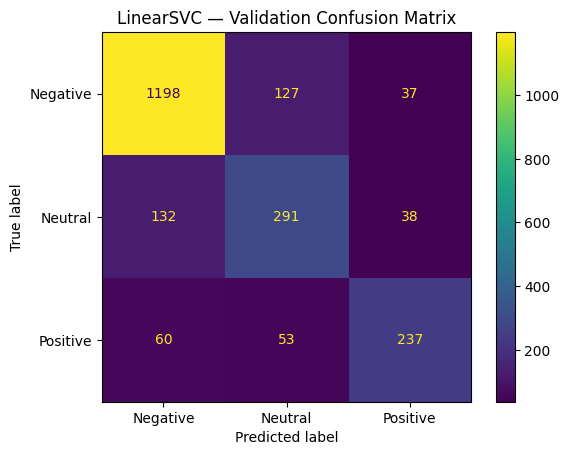

In [85]:
#LinearSVC Confusion Matrix

linear_svc_cm = confusion_matrix(
    y_val,
    linear_svc_val_pred,
    labels=["negative", "neutral", "positive"]
)

ConfusionMatrixDisplay(
    confusion_matrix=linear_svc_cm,
    display_labels=["Negative", "Neutral", "Positive"]
).plot()

plt.title("LinearSVC — Validation Confusion Matrix")
plt.show()

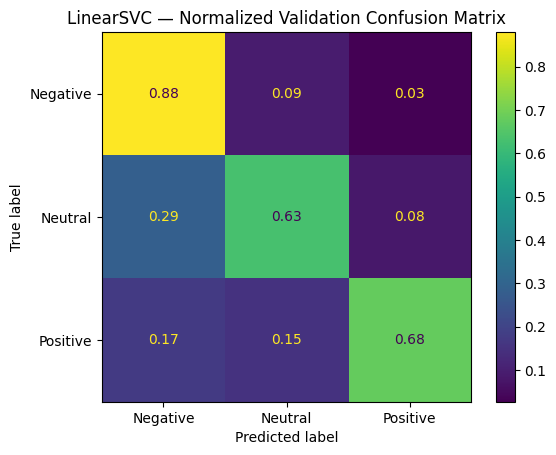

In [86]:
#Normalized Confusion Matrix

linear_svc_cm_normalized = confusion_matrix(
    y_val,
    linear_svc_val_pred,
    labels=["negative", "neutral", "positive"],
    normalize="true"
)

ConfusionMatrixDisplay(
    confusion_matrix=linear_svc_cm_normalized,
    display_labels=["Negative", "Neutral", "Positive"]
).plot(
    values_format=".2f"
)

plt.title("LinearSVC — Normalized Validation Confusion Matrix")
plt.show()

In [87]:
#Model Comparison

model_results = pd.DataFrame({
    "Model": [
        "DummyClassifier",
        "VADER",
        "Logistic Regression",
        "LinearSVC",
        "BiLSTM"
    ],
    "Accuracy": [
        dummy_accuracy,
        vader_accuracy,
        logistic_accuracy,
        linear_svc_accuracy,
        bilstm_accuracy
    ],
    "Macro_F1": [
        dummy_macro_f1,
        vader_macro_f1,
        logistic_macro_f1,
        linear_svc_macro_f1,
        bilstm_macro_f1
    ],
    "Weighted_F1": [
        f1_score(y_val, dummy_val_pred, average="weighted"),
        f1_score(y_val, vader_val_pred, average="weighted"),
        logistic_weighted_f1,
        linear_svc_weighted_f1,
        bilstm_weighted_f1
    ]
})

model_results.sort_values(
    "Macro_F1",
    ascending=False
)

,Model,Accuracy,Macro_F1,Weighted_F1
2,Logistic Regression,0.792913,0.748408,0.797071
3,LinearSVC,0.794294,0.737038,0.793508
4,BiLSTM,0.778187,0.704872,0.774548
1,VADER,0.545329,0.510735,0.567010
0,DummyClassifier,0.626783,0.256860,0.482987


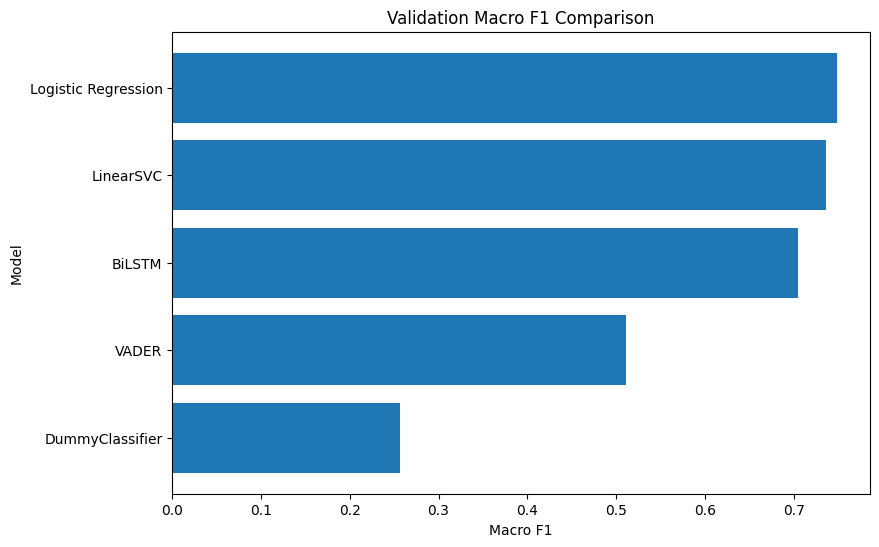

In [88]:
#Model Comparison Plot

comparison_plot = model_results.sort_values(
    "Macro_F1",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    comparison_plot["Model"],
    comparison_plot["Macro_F1"]
)

plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.title("Validation Macro F1 Comparison")

plt.show()

In [89]:
#Class-Wise Metrics

logistic_report = classification_report(
    y_val,
    logistic_val_pred,
    output_dict=True
)

linear_svc_report = classification_report(
    y_val,
    linear_svc_val_pred,
    output_dict=True
)

class_metrics = pd.DataFrame({
    "Logistic Regression": {
        "Negative F1": logistic_report["negative"]["f1-score"],
        "Neutral F1": logistic_report["neutral"]["f1-score"],
        "Positive F1": logistic_report["positive"]["f1-score"]
    },
    "LinearSVC": {
        "Negative F1": linear_svc_report["negative"]["f1-score"],
        "Neutral F1": linear_svc_report["neutral"]["f1-score"],
        "Positive F1": linear_svc_report["positive"]["f1-score"]
    }
})

class_metrics.round(4)

,Logistic Regression,LinearSVC
Negative F1,0.8633,0.8706
Neutral F1,0.6533,0.6245
Positive F1,0.7286,0.7160


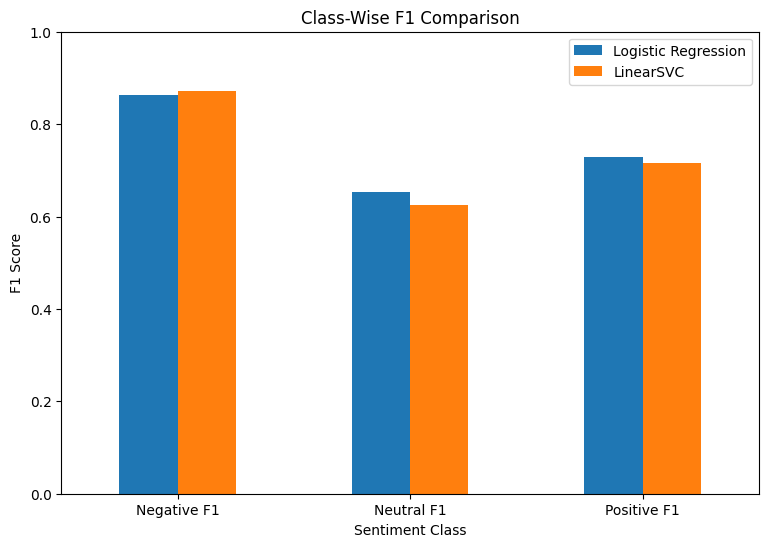

In [90]:
#Class-Wise F1 Plot

class_metrics.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.ylabel("F1 Score")
plt.xlabel("Sentiment Class")
plt.title("Class-Wise F1 Comparison")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

In [91]:
# BERTweet Test Evaluation

bertweet_output = bertweet_trainer.predict(test_dataset)

bertweet_test_pred = np.argmax(
    bertweet_output.predictions,
    axis=1
)

bertweet_test_labels = [
    id2label[i] for i in bertweet_test_pred
]

bertweet_accuracy = accuracy_score(y_test, bertweet_test_labels)
bertweet_macro_f1 = f1_score(y_test, bertweet_test_labels, average="macro")
bertweet_weighted_f1 = f1_score(y_test, bertweet_test_labels, average="weighted")

print("Accuracy    :", round(bertweet_accuracy,4))
print("Macro F1    :", round(bertweet_macro_f1,4))
print("Weighted F1 :", round(bertweet_weighted_f1,4))

print(classification_report(y_test, bertweet_test_labels, digits=4))

Accuracy    : 0.8679
Macro F1    : 0.8236
Weighted F1 : 0.8671
              precision    recall  f1-score   support

    negative     0.9198    0.9340    0.9268      1363
     neutral     0.7433    0.7239    0.7335       460
    positive     0.8211    0.8000    0.8104       350

    accuracy                         0.8679      2173
   macro avg     0.8281    0.8193    0.8236      2173
weighted avg     0.8665    0.8679    0.8671      2173



In [92]:
#Final Model Selection

final_results = pd.DataFrame({
    "Model":[
        "DummyClassifier",
        "VADER",
        "Logistic Regression",
        "LinearSVC",
        "BiLSTM",
        "BERTweet"
    ],
    "Accuracy":[
        dummy_accuracy,
        vader_accuracy,
        logistic_accuracy,
        linear_svc_accuracy,
        bilstm_accuracy,
        bertweet_accuracy
    ],
    "Macro_F1":[
        dummy_macro_f1,
        vader_macro_f1,
        logistic_macro_f1,
        linear_svc_macro_f1,
        bilstm_macro_f1,
        bertweet_macro_f1
    ],
    "Weighted_F1":[
        f1_score(y_val,dummy_val_pred,average="weighted"),
        f1_score(y_val,vader_val_pred,average="weighted"),
        logistic_weighted_f1,
        linear_svc_weighted_f1,
        bilstm_weighted_f1,
        bertweet_weighted_f1
    ]
})

final_results.sort_values("Macro_F1",ascending=False)

,Model,Accuracy,Macro_F1,Weighted_F1
5,BERTweet,0.867925,0.823576,0.867150
2,Logistic Regression,0.792913,0.748408,0.797071
3,LinearSVC,0.794294,0.737038,0.793508
4,BiLSTM,0.778187,0.704872,0.774548
1,VADER,0.545329,0.510735,0.567010
0,DummyClassifier,0.626783,0.256860,0.482987


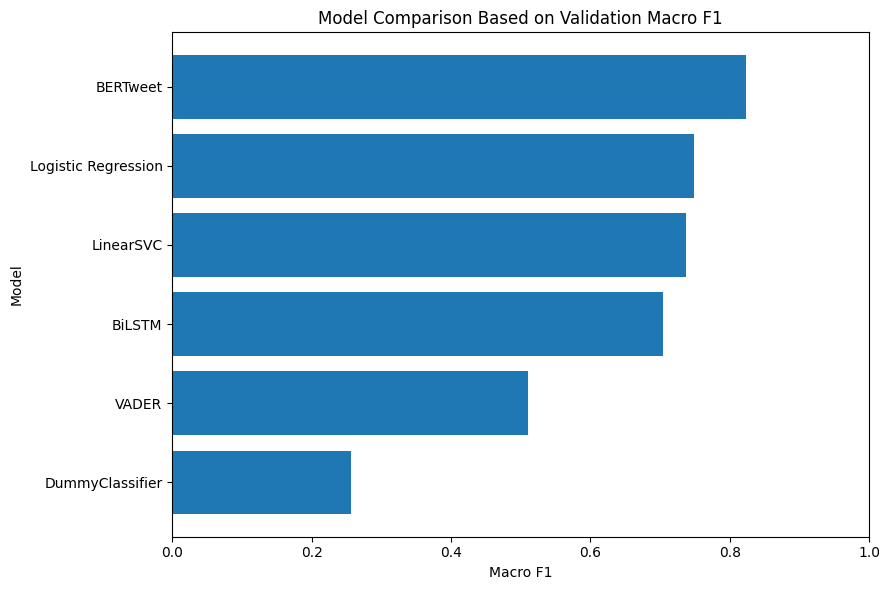

In [93]:
#  Best Model Plot

plot_data = final_results.sort_values(
    "Macro_F1",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data["Model"],
    plot_data["Macro_F1"]
)

plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.title("Model Comparison Based on Validation Macro F1")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

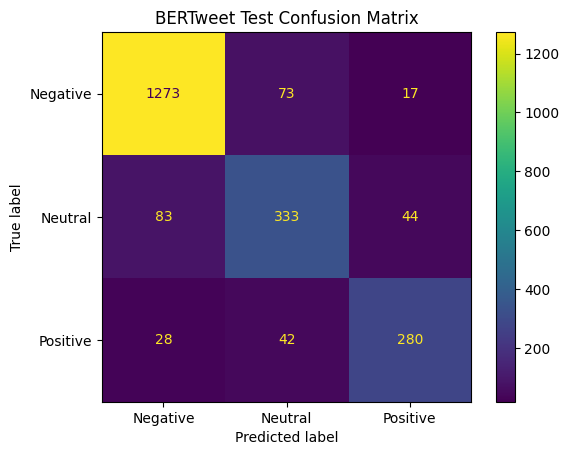

In [94]:
#Final Confusion Matrix

final_cm = confusion_matrix(
    y_test,
    bertweet_test_labels,
    labels=["negative","neutral","positive"]
)

ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Negative","Neutral","Positive"]
).plot()

plt.title("BERTweet Test Confusion Matrix")
plt.show()

In [95]:
#Error Analysis

error_df = pd.DataFrame({
    "Tweet": X_test.reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
    "Predicted": bertweet_test_labels,
    "Airline": airline_test.reset_index(drop=True)
})

errors = error_df[
    error_df["Actual"] != error_df["Predicted"]
].copy()

print("Total Errors:", len(errors))

errors.head(10)

Total Errors: 287


,Tweet,Actual,Predicted,Airline
0,<USER> Hi Guys good morning how are you doing,positive,neutral,Southwest
40,<USER> your beautiful front-end design is down...,positive,negative,Virgin America
42,"<USER> no, they're too busy being awesome and ...",positive,negative,Delta
44,<USER> hilarious,negative,positive,United
47,<USER> such a bummer. But I understand it's a ...,neutral,positive,Delta
60,<USER> sprinted from C concourse to E and just...,neutral,positive,United
86,<USER> when AA gate supervisor 600117 was aske...,neutral,negative,US Airways
89,<USER> Hi! Just got my TSA pre-check # &amp; p...,negative,neutral,Southwest
97,<USER> <USER> So I contacted my bank. They too...,neutral,negative,US Airways
101,<USER> all 4 of us are on standby in Houston t...,negative,neutral,United


In [96]:
# Error Category

errors["Reason"] = ""

errors.loc[
    errors["Tweet"].str.contains("not|never|no",case=False,regex=True),
    "Reason"
] = "Negation"

errors.loc[
    errors["Tweet"].str.contains("!",regex=False),
    "Reason"
] = errors["Reason"].replace("", "Strong Emotion")

errors.loc[
    errors["Reason"]=="",
    "Reason"
] = "Mixed/Context"

errors[
    ["Tweet","Actual","Predicted","Reason"]
].head(10)

,Tweet,Actual,Predicted,Reason
0,<USER> Hi Guys good morning how are you doing,positive,neutral,Mixed/Context
40,<USER> your beautiful front-end design is down...,positive,negative,Negation
42,"<USER> no, they're too busy being awesome and ...",positive,negative,Negation
44,<USER> hilarious,negative,positive,Mixed/Context
47,<USER> such a bummer. But I understand it's a ...,neutral,positive,Negation
60,<USER> sprinted from C concourse to E and just...,neutral,positive,Negation
86,<USER> when AA gate supervisor 600117 was aske...,neutral,negative,Mixed/Context
89,<USER> Hi! Just got my TSA pre-check # &amp; p...,negative,neutral,Negation
97,<USER> <USER> So I contacted my bank. They too...,neutral,negative,Mixed/Context
101,<USER> all 4 of us are on standby in Houston t...,negative,neutral,Mixed/Context


In [97]:
#Airline Error Analysis

airline_error = (
    errors.groupby("Airline")
    .size()
    .reset_index(name="Errors")
)

airline_total = (
    airline_test.reset_index(drop=True)
    .value_counts()
    .reset_index()
)

airline_total.columns = ["Airline","Total"]

airline_error = airline_total.merge(
    airline_error,
    on="Airline",
    how="left"
)

airline_error["Errors"] = airline_error["Errors"].fillna(0)

airline_error["Error_Rate"] = (
    airline_error["Errors"] /
    airline_error["Total"] * 100
).round(2)

airline_error

,Airline,Total,Errors,Error_Rate
0,United,578,79,13.67
1,US Airways,436,48,11.01
2,American,396,35,8.84
3,Southwest,378,60,15.87
4,Delta,309,49,15.86
5,Virgin America,76,16,21.05


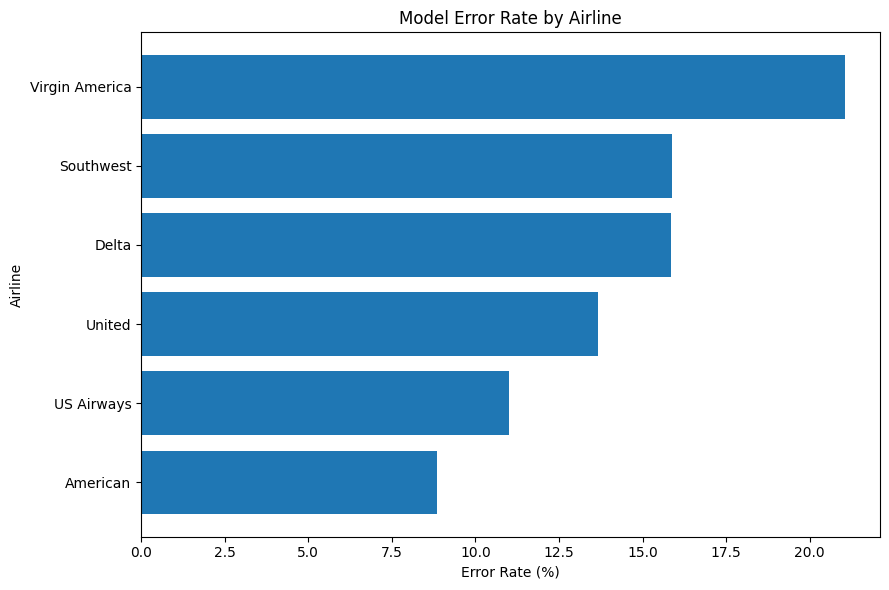

In [98]:
#Airline Error Plot

plot_data = airline_error.sort_values(
    "Error_Rate",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data["Airline"],
    plot_data["Error_Rate"]
)

plt.xlabel("Error Rate (%)")
plt.ylabel("Airline")
plt.title("Model Error Rate by Airline")

plt.tight_layout()
plt.show()

In [99]:
#Robustness Analysis

sample_tweets = pd.Series([
    "The flight was delayed again.",
    "Amazing customer service today!",
    "The food was okay, nothing special.",
    "I am never flying this airline again."
])

sample_predictions = logistic_model.predict(sample_tweets)

robustness_df = pd.DataFrame({
    "Tweet": sample_tweets,
    "Prediction": sample_predictions
})

robustness_df

,Tweet,Prediction
0,The flight was delayed again.,negative
1,Amazing customer service today!,positive
2,"The food was okay, nothing special.",negative
3,I am never flying this airline again.,negative


In [100]:
# Save Best Model

joblib.dump(
    logistic_model,
    "lab05_outputs/models/logistic_pipeline.joblib"
)

print("Model saved successfully.")

Model saved successfully.


In [101]:
# Reload Verification

loaded_model = joblib.load(
    "lab05_outputs/models/logistic_pipeline.joblib"
)

sample = [
    "The crew was very friendly and helpful."
]

print("Prediction:", loaded_model.predict(sample)[0])

Prediction: positive


In [102]:
# Export Predictions

prediction_df = pd.DataFrame({
    "Tweet": X_test.reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
    "Predicted": bertweet_test_labels
})

prediction_df.to_csv(
    "lab05_outputs/Test_Predictions.csv",
    index=False
)

print("Predictions exported.")

Predictions exported.


In [103]:
# Export Error Analysis

errors.to_csv(
    "lab05_outputs/Error_Analysis.csv",
    index=False
)

print("Error analysis exported.")

Error analysis exported.
